<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Clase03_Note3_de_3_Introducci%C3%B3n_a_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Predicción de Series Temporales con Redes Neuronales LSTM

Este notebook demuestra cómo usar **Redes Neuronales Recurrentes (RNN)**, específicamente **Long Short-Term Memory (LSTM)**, para predecir precios de acciones.

### 🧠 ¿Por qué LSTM?
- Capturan dependencias temporales (memoria del pasado).
- Manejan problemas de gradientes desvanecidos.
- Son ideales para **series temporales**: clima, demanda, cotizaciones, etc.

Aquí entrenaremos un modelo para **predecir el precio de cierre de Apple (AAPL)** usando datos históricos.

## ⚙️ Paso 0: Configuración y Librerías

In [ ]:
import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout

# GPU setup (safe)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU activa: {gpus[0].name}")
    except RuntimeError:
        print("⚠️ GPU ya inicializada, continuando...")
else:
    print("⚠️ Sin GPU, se usará CPU (más lento).")

✅ GPU activa: /physical_device:GPU:0


## 📥 Paso 1: Carga y Preparación de Datos
Usaremos `pandas_datareader` para obtener datos de Yahoo Finance. Luego normalizaremos los valores con `MinMaxScaler` a un rango `[0,1]`.

/tmp/ipython-input-1583146690.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


📊 Datos descargados: 2515 filas


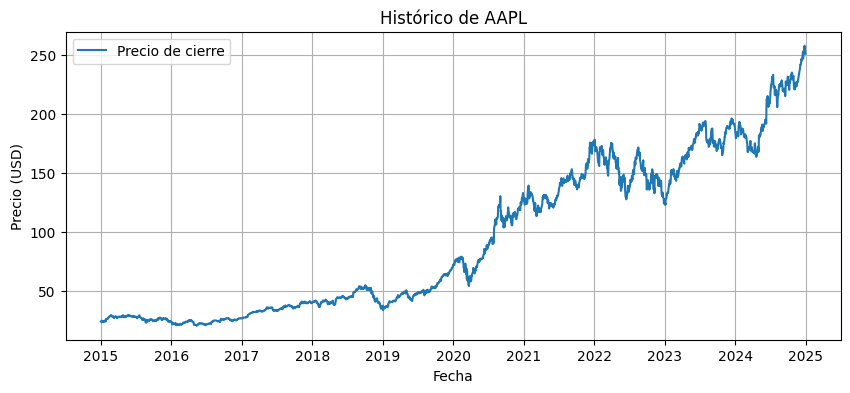

In [ ]:
!pip install yfinance --quiet
import yfinance as yf

symbol = 'AAPL'
data = yf.download(symbol, start='2015-01-01', end='2024-12-31')
print(f"📊 Datos descargados: {data.shape[0]} filas")

# Usaremos solo la columna 'Close'
prices = data[['Close']].values
plt.figure(figsize=(10,4))
plt.plot(data['Close'], label='Precio de cierre')
plt.title(f'Histórico de {symbol}')
plt.xlabel('Fecha'); plt.ylabel('Precio (USD)'); plt.legend(); plt.grid(True); plt.show()

# Normalización
scaler = MinMaxScaler(feature_range=(0,1))
scaled_prices = scaler.fit_transform(prices)

## 🧩 Paso 2: Crear Secuencias para el Modelo
Para que el modelo aprenda patrones temporales, convertimos los datos en ventanas deslizantes. Cada entrada (`X`) contiene `look_back` días previos y la salida (`y`) es el valor del siguiente día.

In [ ]:
look_back = 60  # número de días pasados usados para predecir el siguiente

def create_sequences(dataset, look_back=60):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_prices, look_back)

# División 80/20 entrenamiento - prueba
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Redimensionar para LSTM: (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"✅ Datos preparados: {X_train.shape[0]} muestras de entrenamiento")

✅ Datos preparados: 1964 muestras de entrenamiento


## 🧠 Paso 3: Construir y Entrenar el Modelo LSTM

In [ ]:
model = Sequential([
    Input(shape=(look_back, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)
print(f"⏱️ Tiempo total: {time.time()-start:.2f} s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0328 - val_loss: 9.5724e-04
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.5685e-04 - val_loss: 0.0013
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.8993e-04 - val_loss: 7.6913e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 0.0062
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.2260e-04 - val_loss: 0.0039
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.2743e-04 - val_loss: 0.0018
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.0082e-04 - val_loss: 0.0023
⏱️ Tiempo total: 18.41 s


## 📉 Paso 4: Evaluación del Modelo

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
📊 Error RMSE: 11.478 USD


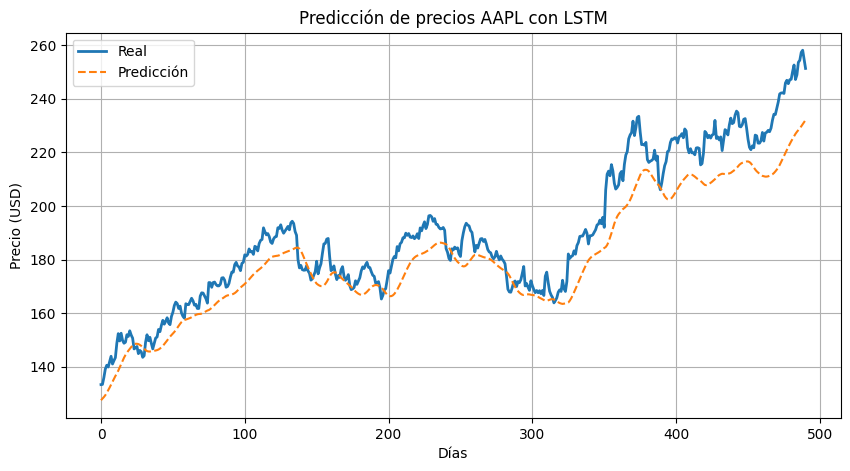

In [ ]:
# Predicciones
predictions = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predictions)
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Error cuadrático medio (RMSE)
rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))
print(f"📊 Error RMSE: {rmse:.3f} USD")

# Gráfica comparativa
plt.figure(figsize=(10,5))
plt.plot(real_prices, label='Real', linewidth=2)
plt.plot(predicted_prices, label='Predicción', linestyle='--')
plt.title(f'Predicción de precios {symbol} con LSTM')
plt.xlabel('Días'); plt.ylabel('Precio (USD)'); plt.legend(); plt.grid(True)
plt.show()

## 💾 Paso 5: Guardar el Modelo (opcional)

In [ ]:
model.save('modelo_lstm_aapl.keras')
print('✅ Modelo guardado como modelo_lstm_aapl.keras')

✅ Modelo guardado como modelo_lstm_aapl.keras


## ✅ Conclusiones
- Las **LSTM** logran capturar patrones de tendencia en series temporales.
- El modelo puede mejorarse aumentando el número de épocas o neuronas.
- A pesar de su simplicidad, logra aproximar correctamente los movimientos del precio.

👉 *Siguiente paso:* probar con más variables (volumen, indicadores técnicos) o modelos híbridos CNN-LSTM.